Connected to ni-vedo-env (Python 3.14.0)

 # Notebook 02: Surface curvature mapping

 **Paper section:** Results — Surface curvature mapping
 **Paper figures:** Figs. 3 (Gaussian curvature), 4 (Mean curvature)

 This script computes the local Gaussian and Mean curvature at every vertex
 of the basal surface mesh.

 **Method:** For each vertex, a polynomial quadric surface is fitted to the
 local neighbourhood.  The principal curvatures k1 (maximum) and k2 (minimum)
 are extracted from this quadric, giving:
 - Gaussian curvature K = k1 × k2  (µm⁻²)
 - Mean curvature H = (k1 + k2) / 2  (µm⁻¹)

 Before fitting, the mesh is decimated so that the median face area matches
 `good_size` — this ensures consistent, resolution-independent curvature
 estimates.

 **Output:** `basal-curvatures.npy` — array of shape (N, 7) with columns
 X, Y, Z, K, H, k1, k2.

In [1]:
from vedo import settings
settings.default_backend = "vtk"

from spatchcocking import *
import spatchcocking as sp
import numpy as np
import os

 ## Parameters

 Adjust these before running the notebook.

In [2]:
# --- Output ---
save_name = "../data/example/basal"   # prefix for the .npy output file

# --- Mesh quality ---
good_size = 1000          # target median face area (µm²); increase → coarser mesh

# --- Curvature fitting ---
curvature_depth  = 5      # neighbourhood ring depth for quadric fitting
curvature_degree = 2      # polynomial degree (2 = quadric)

 ## Helper: decimate to target face size

 `compute_quality(metric=28)` stores the face area (µm²) in `celldata['Quality']`.
 We compute the scale factor so that the median area reaches `good_size`,
 then decimate with regularization to keep a uniform triangle distribution.

In [3]:
def decimate_to_size(mesh, good_size):
    """Decimate mesh so that median face area ≈ good_size µm²."""
    mesh.compute_quality(metric=28)
    original_size = np.median(mesh.celldata["Quality"])

    scale = original_size / good_size
    if scale > 1:          # mesh already coarser than target — minimal decimate
        scale = 0.999

    mesh_dec = mesh.clone().decimate(fraction=scale, regularization=1)
    mesh_dec.compute_quality(metric=28)
    new_size = np.median(mesh_dec.celldata["Quality"])

    print(f"  Median face area: {original_size:.1f} → {new_size:.1f} µm²  "
          f"(target {good_size} µm²)")
    show([mesh, mesh_dec], N=2).close()
    return mesh_dec

 ## Load and decimate basal mesh

In [4]:
basal = Mesh("../data/example/basal.ply")
print("Basal:")
basal_dec = decimate_to_size(basal, good_size)

Basal:
  Median face area: 1628.0 → 1628.3 µm²  (target 1000 µm²)


 ## Compute curvatures

 Check if a cached `.npy` file already exists; if so, ask before rerunning
 (curvature fitting can be slow on large meshes).

In [5]:
npy_file = f"{save_name}-curvatures.npy"
run_computation = True

if os.path.exists(npy_file):
    answer = input(f"'{npy_file}' already exists. Rerun analysis? [y/N]: ")
    run_computation = answer.strip().lower() == "y"

if run_computation:
    basal_dec = sp.compute_and_save_curvatures(
        basal_dec,
        depth=curvature_depth,
        degree=curvature_degree,
        save_name=save_name,
    )
    print("Curvature analysis complete.")
else:
    # Load from cached .npy and assign back to mesh vertices
    # columns: X, Y, Z, Gauss_Curvature, Mean_Curvature, K1, K2
    data = np.load(npy_file)
    if len(data) != basal_dec.npoints:
        print("Warning: point count mismatch — rerunning computation.")
        basal_dec = sp.compute_and_save_curvatures(
            basal_dec,
            depth=curvature_depth,
            degree=curvature_degree,
            save_name=save_name,
        )
    else:
        basal_dec.pointdata["Gauss_Curvature"] = data[:, 3]
        basal_dec.pointdata["Mean_Curvature"]  = data[:, 4]
        basal_dec.pointdata["K1"] = data[:, 5]
        basal_dec.pointdata["K2"] = data[:, 6]
        print(f"Loaded curvatures from {npy_file}")

Calculating surface curvatures...
━━━━━━━━━━━━━━━━━━━━━ elapsed: 4s (834.5 it/s)0mK
Saved curvature data to: ../data/example/basal-curvatures.npy
Curvature analysis complete.


In [6]:
K_b  = basal_dec.pointdata["Gauss_Curvature"]
H_b  = basal_dec.pointdata["Mean_Curvature"]
K1_b = basal_dec.pointdata["K1"]
K2_b = basal_dec.pointdata["K2"]

print(f"K : min={K_b.min():.2e}  max={K_b.max():.2e}  mean={K_b.mean():.2e}")
print(f"H : min={H_b.min():.2e}  max={H_b.max():.2e}  mean={H_b.mean():.2e}")

K : min=-4.30e-05  max=3.21e-05  mean=1.40e-06
H : min=-4.15e-03  max=8.12e-03  mean=1.94e-03


 ## Visualize — 2×2 curvature map

 Each panel shows one curvature field mapped onto the 3D mesh.
 Colour range is clipped at ±3 σ to suppress outlier vertices.

In [7]:
fields = [
    ("Gauss_Curvature", K_b,  "PiYG",     "K  (µm⁻²)"),
    ("Mean_Curvature",  H_b,  "RdBu_r",   "H  (µm⁻¹)"),
    ("K1",              K1_b, "Spectral_r","k1 (µm⁻¹)"),
    ("K2",              K2_b, "Spectral_r","k2 (µm⁻¹)"),
]

p = Plotter(shape=(2, 2), offscreen=False, size=(1200, 1000))
for i, (arr, vals, cmap, label) in enumerate(fields):
    m = basal_dec.clone()
    m.pointdata.select(arr)
    vmin, vmax = sp.getTightercmap(vals)
    vlim = max(abs(vmin), abs(vmax))
    m.cmap(cmap, vmin=-vlim, vmax=vlim)
    p.at(i).show(m, axes=0)
    p.at(i).add(Text2D(f"Basal — {label}", pos="top-middle", s=0.8))

p.show().interactive().close()

vedo.plotter.runtime.Plotter
n. of objects : 8 (14976 vertices)
bounds        : x=(139, 1.91e+3), y=(645, 3.35e+3), z=(1.35e+3, 4.92e+3)
axes style    : 0 (no axes)

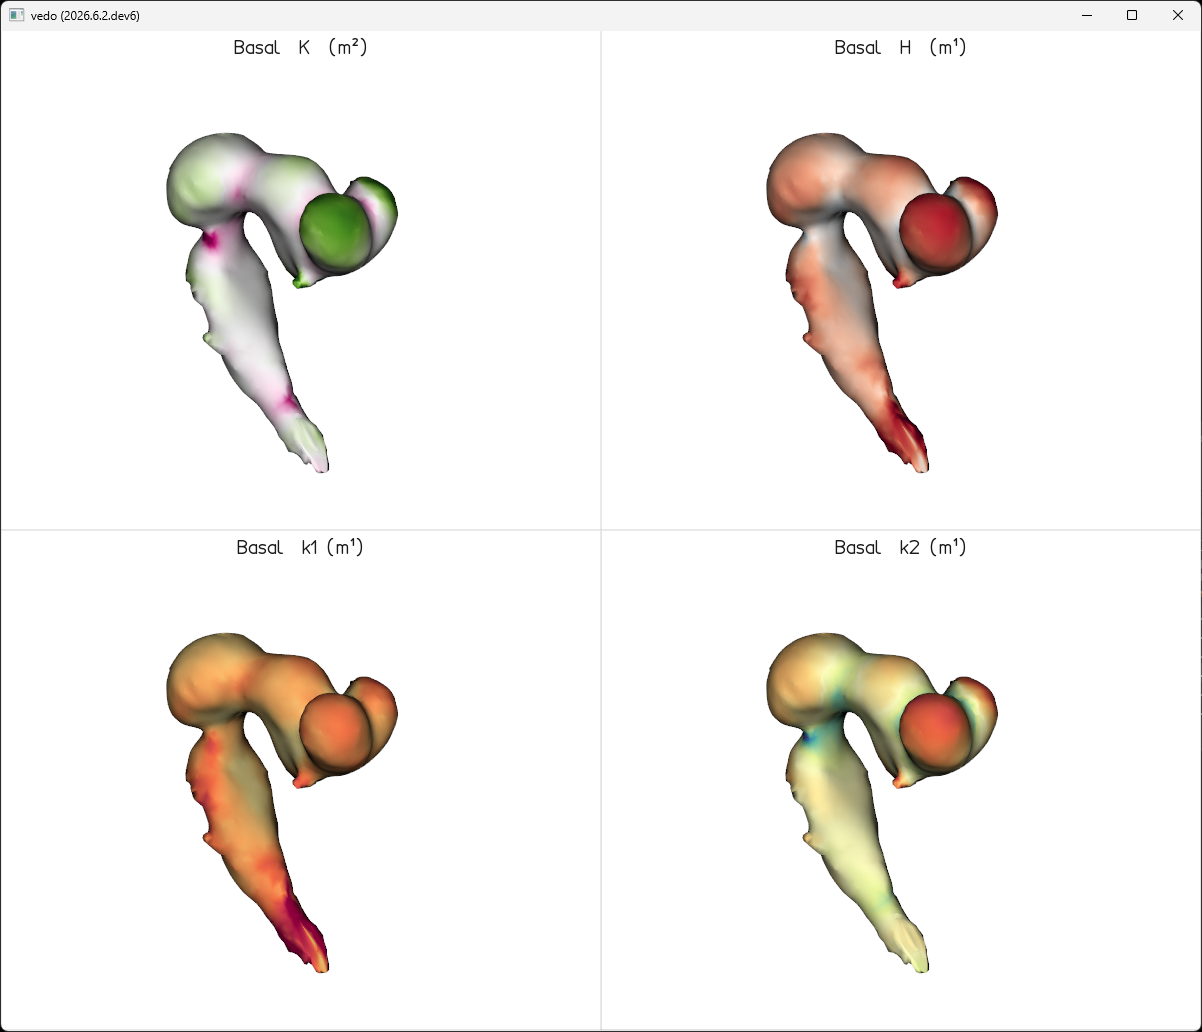